# Test case LVV-T956-a: Impacted Ghost Area

> **Percentage of image area that can have ghosts with surface brightness gradient amplitude of more than 1/3 of the sky noise over 1 arcsec shall be less than 1% of the area**

This test verifies the following requirements:

- LSR-REQ-0093-V-10: Ghost Image Control - Image Area Affected (https://rubinobs.atlassian.net/browse/LVV-20652)

Authors: Aashay Pai, Alex Drlica-Wagner, Lee Kelvin


In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# For running on the RSP
consdb_url = "http://consdb-pq.consdb:8080/consdb/"
#consdb_token = None

# For running locally
# consdb_url = "https://usdf-rsp.slac.stanford.edu/consdb"
consdb_token = ""

In [23]:
# rayven is a package built to connect LSST tools with Batoid to simulate ghosts
import os
import lsst.sitcom.sciunit.lsb.rayven as rv
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from copy import deepcopy
import healpy as hp
from scipy.stats import binned_statistic_2d

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astroquery.vizier import Vizier

from lsst.summit.utils import ConsDbClient
import lsst.afw.cameraGeom as afwCameraGeom

#### Methodology

We will measure the impacted area using ghost simulations using the Batoid ray-tracing package and the skynoise data stored in the ConsDB.

The following will be executed for each visit:
- Retrieve V band magnitudes for bright stars in the FoV of the boresight from the Yale Bright Star Catalog
- Convert the V-band magnitudes to DES magnitudes, which are then converted to LSST magnitudes using `the_monster` catalog.
- Convert the transformed LSST magnitudes to instrumental flux using the median zeropoint of the visit
- Set the reflectances of the optics in Batoid to the `syseng_throughputs` values
- Inject the bright stars with their respective instrumental fluxes into the Batoid simulation using the WCS
- Carry out a ray-tracing simulation through the entire system and save each individual ghost (and its flux) created by each star, labelled by the optical elements responsible for producing that ghost
- Retrive the median skynoise for each detector from the ConsDB

Then, for each ghost from each star: 
- Divide the total ghost flux in each detector by the median skynoise
- If this ratio exceeds 1/3 in any detector, mark the ghost to be "impacting"
- calculate the total area of the ghost on the focal plane by binning the ghost at the sub-detector level (25x25 bins in each detector)

## Simulate Ghosts Using Batoid & Rayven


In [17]:
visit = 2025071700171
gt = rv.GhostTool(v isit=visit, consdb_url=consdb_url, consdb_token=consdb_token)
tab = deepcopy(gt.camera_geometry.det_geometry_table)

http://consdb-pq.consdb:8080/consdb/


In [5]:
gfs = gt.batoid_simulator.simulate_fov()

/tmp/ipykernel_13524/1400056721.py:2: RuntimeWarning: divide by zero encountered in log10
  np.log10(gfs.bin(500)),


Text(0.5, 1.0, 'Batoid Ghost Simulation \n visit: 2025071700171 \n band: u')

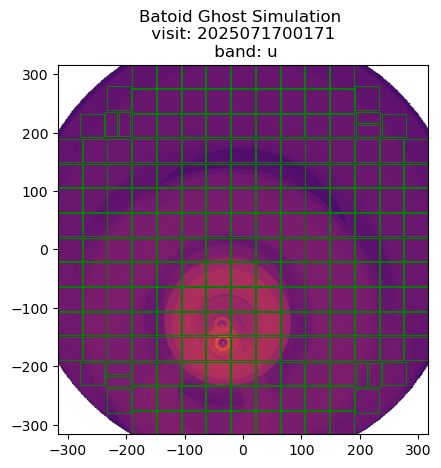

In [6]:
plt.imshow(
    np.log10(gfs.bin(500)),
    cmap="inferno",
    extent=(
        rv.LSSTCamConstants.fp_min_x.value,
        rv.LSSTCamConstants.fp_max_x.value,
        rv.LSSTCamConstants.fp_min_y.value,
        rv.LSSTCamConstants.fp_max_y.value,
    ),
)

for j in range(205):
    min_x = tab["min_x"]
    min_y = tab["min_y"]

    max_x = tab["max_x"]
    max_y = tab["max_y"]
    plt.vlines(min_x, min_y, max_y, color="g", lw=0.5)
    plt.hlines(min_y, min_x, max_x, color="g", lw=0.5)
    plt.vlines(max_x, min_y, max_y, color="g", lw=0.5)
    plt.hlines(max_y, min_x, max_x, color="g", lw=0.5)

plt.title(f"Batoid Ghost Simulation \n visit: {visit} \n band: {gt.obs_params.band}")

## Setup


Calculate edges of each detector to bin the ghosts per detector.


In [7]:
x_binsize, y_binsize = [], []

x_detectors = [75, 76, 77, 84, 85, 86, 93, 94, 95, 102, 103, 104, 111, 112, 113]
y_detectors = [10, 13, 16, 46, 49, 52, 91, 94, 97, 136, 139, 142, 172, 175, 178]

for i, j in zip(x_detectors, x_detectors[1:]):
    x_binsize.append(tab[tab["detector"] == j]["max_x"] - tab[tab["detector"] == i]["max_x"])

for i, j in zip(y_detectors, y_detectors[1:]):
    y_binsize.append(tab[tab["detector"] == j]["min_y"] - tab[tab["detector"] == i]["min_y"])

x_bins = [
    tab[tab["detector"] == x_detectors[0]]["min_x"].value + np.sum(x_binsize[:i])
    for i in range(len(x_binsize) + 1)
]
x_bins.append(tab[tab["detector"] == x_detectors[-1]]["max_x"].value)

y_bins = [
    tab[tab["detector"] == y_detectors[0]]["min_y"].value + np.sum(y_binsize[:i])
    for i in range(len(y_binsize) + 1)
]
y_bins.append(tab[tab["detector"] == y_detectors[-1]]["max_y"].value)

In [8]:
detids = np.zeros((np.size(x_detectors), np.size(y_detectors)))
for i in range(detids.shape[0]):
    for j in range(detids.shape[1]):

        counter = 0
        for det in gt.data_products["camera"]:
            center = det.getCenter(afwCameraGeom.FOCAL_PLANE)

            if (x_bins[i] < center[0] < x_bins[i + 1]) & (y_bins[j] < center[1] < y_bins[j + 1]):
                # print(det.getId())
                counter += 1
                detids[j, i] = det.getId()
        if counter == 0:
            detids[j, i] = 0  # np.nan

detids = np.flipud(detids)

detids[0:3, 0:3] = np.nan
detids[0:3, 12:15] = np.nan
detids[12:15, 0:3] = np.nan
detids[12:15, 12:15] = np.nan

## Fetch Sky Noise from ConsDB


get the ccdvisit1_quicklook table from ConsDB that contains the sky noise and sky background values per detector


In [9]:
os.environ["no_proxy"] += ",.consdb"
os.environ["no_proxy"] += ",.slac.stanford.edu"
query = f"""
        SELECT q.sky_bg, q.sky_noise, v.ccdvisit_id, v.visit_id, v.detector 
        from cdb_lsstcam.ccdvisit1 AS v, cdb_lsstcam.ccdvisit1_quicklook AS q
        WHERE v.visit_id = {visit} and q.ccdvisit_id = v.ccdvisit_id
        """

client = ConsDbClient(consdb_url)
ccd_table = client.query(query)

In [10]:
det_skynoise = np.zeros_like(detids)
for i in range(detids.shape[0]):
    for j in range(detids.shape[1]):
        if ~np.isnan(detids[i, j]) & np.size(ccd_table[ccd_table["detector"] == detids[i, j]]) > 0:
            det_skynoise[i, j] = ccd_table[ccd_table["detector"] == int(detids[i, j])]["sky_noise"][0]
        else:
            continue

det_skynoise[0:3, 0:3] = np.nan
det_skynoise[0:3, 12:15] = np.nan
det_skynoise[12:15, 0:3] = np.nan
det_skynoise[12:15, 12:15] = np.nan
det_skynoise[4:5, 0:3] = np.nan

Text(0.5, 1.0, 'visit: 2025071700171 \n sky noise')

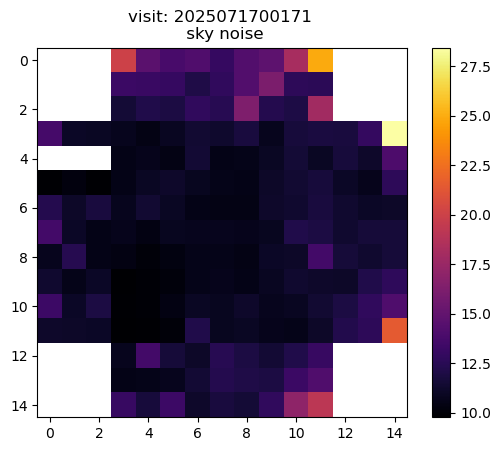

In [11]:
plt.imshow(det_skynoise, cmap="inferno")
plt.colorbar()
plt.title(f"visit: {visit} \n sky noise")

## Bin Ghosts per Detector


In [12]:
tot_ghosts = np.zeros_like(detids)
skynoise_frac = 1 / 3

impacting_ghosts = []

for sgs in gfs:
    for ghost in sgs:
        # do not include flux from star
        if ghost.name == "Star":
            continue

        # bin the ghost into 15x15 grid (1 bin = 1 CCD)
        h = ghost.bin(15)

        nonzero_det_mask = (h != 0) & np.isfinite(detids)
        nonzero_detectors = detids[nonzero_det_mask]
        det_areas = np.zeros_like(h)

        # calculate the area that each ghost occupies on each detector
        detbins = 25
        for det in nonzero_detectors:
            corners = tab[tab["detector"] == det]
            g, _, _, _ = binned_statistic_2d(
                ghost.x,
                ghost.y,
                values=ghost.flux,
                bins=[int(detbins), int(detbins)],
                range=[
                    [corners["min_x"].value, corners["max_x"].value],
                    [corners["min_y"].value, corners["max_y"].value],
                ],
                statistic="sum",
            )
            g = np.flipud(g.T)

            ##get bin size in mm
            x_binsize = (corners["max_x"] - corners["min_x"]) / detbins
            y_binsize = (corners["max_y"] - corners["min_y"]) / detbins

            area = np.count_nonzero(g) * x_binsize * y_binsize

            # convert area to pixel^2
            area_px = area * (rv.LSSTCamConstants.mm_to_pixel) ** 2
            # print(area_px)
            idx = np.where(detids == int(det))
            det_areas[idx] = area_px.value

        # divide ghost flux by area to get units of instrumental flux per pixel
        pred = h / det_areas
        pred[~np.isfinite(pred)] = 0

        # calculate the ghost to sky noise ratio
        ratio = pred / det_skynoise

        # calculate mask for ghosts that cross the ratio > 1/3 threshold
        mask = ratio >= skynoise_frac

        # if more than 1 detectors cross the 1/3 threshold, the ghost is marked as "impacting"
        if np.sum(mask) >= 1:
            impacting_ghosts.append(ghost)
        # fig.suptitle(f'{ghost.name}')
        # fig, ax = plt.subplots(ncols=2)
        # im = ax[0].imshow(ratio)
        # plt.colorbar(im)
        # ax[1].imshow(mask)

        tot_ghosts += pred

/tmp/ipykernel_13524/2571888942.py:49: RuntimeWarning: divide by zero encountered in divide
  pred = h / det_areas
/tmp/ipykernel_13524/2571888942.py:49: RuntimeWarning: invalid value encountered in divide
  pred = h / det_areas


/tmp/ipykernel_13524/3904065404.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(tot_ghosts), cmap="inferno")


Text(0.5, 1.0, 'visit: 2025071700171 \n binned ghosts')

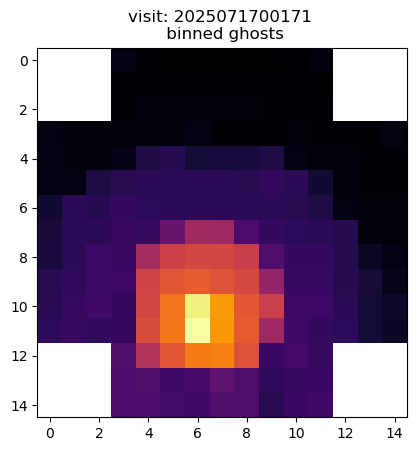

In [13]:
plt.imshow(np.log10(tot_ghosts), cmap="inferno")
plt.title(f"visit: {visit} \n binned ghosts")

## Find Impacting Ghosts


/tmp/ipykernel_13524/3276403561.py:16: RuntimeWarning: divide by zero encountered in log10
  np.log10(binned_impacting_ghosts),


Text(0.5, 1.0, 'impacted area: 354138410.19 px \n fraction: 8.84%')

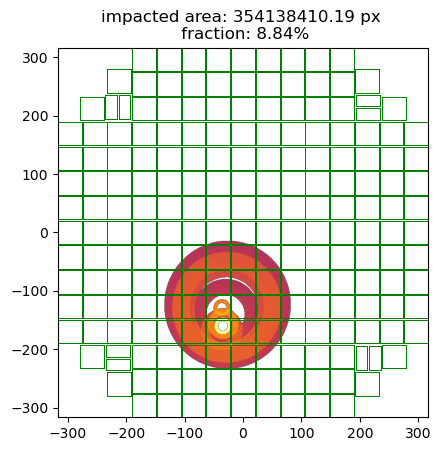

In [14]:
impacting_ghosts = rv.StarGhostSet(ghosts=impacting_ghosts)
binned_impacting_ghosts = impacting_ghosts.bin(1000)

x_binsize = rv.LSSTCamConstants.fp_width / 1000
y_binsize = rv.LSSTCamConstants.fp_height / 1000

# impacted area
impacted_area = (
    np.count_nonzero(binned_impacting_ghosts) * x_binsize * y_binsize * (rv.LSSTCamConstants.mm_to_pixel) ** 2
)
total_area = (
    rv.LSSTCamConstants.fp_width * rv.LSSTCamConstants.fp_height * (rv.LSSTCamConstants.mm_to_pixel) ** 2
)

plt.imshow(
    np.log10(binned_impacting_ghosts),
    cmap="inferno",
    extent=(
        rv.LSSTCamConstants.fp_min_x.value,
        rv.LSSTCamConstants.fp_max_x.value,
        rv.LSSTCamConstants.fp_min_y.value,
        rv.LSSTCamConstants.fp_max_y.value,
    ),
)

for j in range(205):
    min_x = tab["min_x"]
    min_y = tab["min_y"]

    max_x = tab["max_x"]
    max_y = tab["max_y"]
    plt.vlines(min_x, min_y, max_y, color="g", lw=0.5)
    plt.hlines(min_y, min_x, max_x, color="g", lw=0.5)
    plt.vlines(max_x, min_y, max_y, color="g", lw=0.5)
    plt.hlines(max_y, min_x, max_x, color="g", lw=0.5)

plt.title(
    f"impacted area: {impacted_area.value:.2f} px \n fraction: {impacted_area.value/total_area.value*100:.2f}%"
)

# Analysis

**Note**: Due to the 16GB space constraints of the RSP Jupyter Notebooks as well as the intensive processing time (~2-3 minutes per visit), the data in the following section was generated separately, and the final outputs have been used to make the following plots. 

To understand the total impacted area by ghosts, we use the intermittent DRP (`w_2025_37 DRP`) as a sample that is representative of the data that will be collected during normal operations of the observatory. The area of the focal plane impacted by ghosts in this dataset will therefore serve as the "usual" case or "expected" impacted area. However, this number should not be taken at face value, as it omits a lot of nuance that can impact science goals. To show this, we choose 20 visits per band that were selected to be heavily ghosted by visual inspection (we chose 10 visits in the z-band and no visits in the y-band as the visits did not have WCSs generated). This set of visits serve as the "worst" case estimates for the impacted area.

Text(0.5, 0.98, '${\\tt w\\_2025\\_37}$ DRP (${\\tt DM-52496}$)  Ghost Impacted Area')

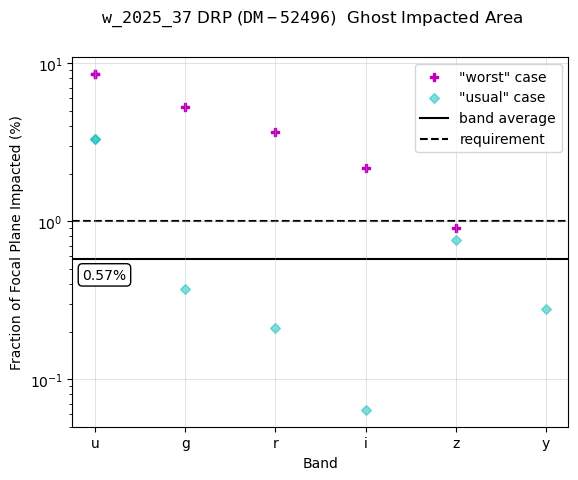

In [28]:
tab = Table.read('../resources/impacted_area/ghost_impacted_area_full_DRP_w_2025_37.csv', format='csv')

fig, ax = plt.subplots()
for band, c in zip(['u', 'g', 'r', 'i', 'z', 'y'], ['b', 'g', 'r', 'orange', 'k', 'm']):

    if band != 'y':
        worst_tab = Table.read(f'../resources/impacted_area/ghost_impacted_area_worst_{band}_band.csv')
        worst_frac = np.sum(worst_tab['impacted_area'])/np.sum(worst_tab['total_area'])
        ax.scatter(band, worst_frac*100, c='m', marker='P', s=30)

        if band =='u':
            ax.scatter(band, worst_frac*100, c='m', marker='P', s=30, label='"worst" case')



    band_tab = tab[tab['band']==band]
    mask = ~band_tab['impacted_area'].mask
    area_frac = np.nansum(band_tab['impacted_area'][mask])/np.nansum(band_tab['total_area'][mask])

    ax.scatter(band, area_frac*100, c='c', s=25, marker='D', alpha=0.5)

    if band=='u':
        ax.scatter(band, area_frac*100, c='c', s=25, marker='D', alpha=0.5, label='"usual" case')

ax.grid(lw=0.5, alpha=0.5)

ax.set_ylabel('Fraction of Focal Plane Impacted (%)')
ax.set_xlabel('Band')

ax.axhline(np.nansum(tab['impacted_area'][~tab['impacted_area'].mask])/np.nansum(tab['total_area'][~tab['impacted_area'].mask])* 100,
          c='k', label='band average', zorder=-1)
ax.text(0.02, 0.4, '0.57%', bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"),
transform=ax.transAxes)
ax.axhline(1, zorder=-1,
          c='k', ls='dashed', label='requirement')

ax.set_yscale('log')
ax.legend()
#ax.set_ylim(0.6, 1.1)
fig.suptitle(r'${\tt w\_2025\_37}$ DRP (${\tt DM-52496}$)  Ghost Impacted Area')
#fig.savefig('ghost_impact_usual_worst_case.png', dpi=300)

We also produce an all-sky map of the area of the focal plane impacted by ghosts. To do so, we first generate a plot of impacted area vs. star magnitude:
- retrieve nominal dark sky noise values from `SMTN-002`: https://smtn-002.lsst.io/
- retrieve nominal zeropoints in each band from `syseng_throughputs` Table 7: https://github.com/lsst-pst/syseng_throughputs/blob/main/notebooks/Syseng%20Throughputs%20Repo%20Demo.ipynb
- scale the values above to 30s exposure times
- inject a single star into a Batoid ray-tracing simulation that has an LSST magnitude between (-3, 12) in each band
- calculate the impacted area by the ghosts produced by this star
- we also place the star at various offsets from the boresight (0, 0.5, 0.75, 1, 1.25, 1.5) degrees off-axis to check if the position of the star changes the impacted area significantly

/tmp/ipykernel_44150/522621491.py:32: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[i].set_ylim(0, 100)


Text(0.5, 1.0, 'r-band off axis')

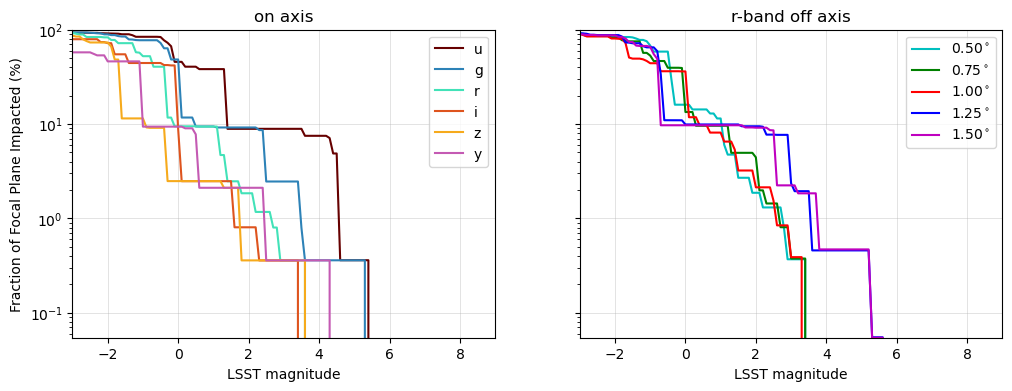

In [14]:
sim_table = Table.read('../resources/impacted_area/ghost_impact_sim.csv')

area_frac = sim_table['impacted_area']/sim_table['total_area']

bands = ['u', 'g', 'r', 'i', 'z', 'y']

fig, ax = plt.subplots(ncols=2, figsize=(12,4), sharey=True)

for band, c in zip(bands, ['#660000', '#2D82B7', '#42E2B8', '#DE541E', '#F6AA1C', '#C45AB3']):
    band_mask = sim_table['band'] == band
    fa_mask = sim_table['fa_y'] == np.deg2rad(0)
    mask = band_mask & fa_mask

    ax[0].plot(sim_table['star_mag'][mask], area_frac[mask]*100, color=c,
             ms=2, label=band)

for angle, c in zip([np.deg2rad(0.5), np.deg2rad(0.75), np.deg2rad(1.0), np.deg2rad(1.25), np.deg2rad(1.5)], 
                    ['c', 'g', 'r', 'b', 'm']):
    band_mask = sim_table['band'] == 'r'
    fa_mask = sim_table['fa_y'] == angle
    mask = band_mask & fa_mask
    
    ax[1].plot(sim_table['star_mag'][mask], area_frac[mask]*100, color=c,
             ms=2, label=f'{np.rad2deg(angle):.2f}'+r'$^\circ$')

for i in range(0, 2):
    ax[i].axhline(0, c='k', zorder=-10)
    
    ax[i].grid(lw=0.5, alpha=0.5)
    ax[i].set_xlabel('LSST magnitude')

    ax[i].set_ylim(0, 100)
    ax[i].set_xlim(-3, 9)
    
    ax[i].legend()
    ax[i].set_yscale('log')
    
ax[0].set_ylabel('Fraction of Focal Plane Impacted (%)')
ax[0].set_title('on axis')
ax[1].set_title('r-band off axis')

From the plot above, we see that fainter off-axis stars produce a slightly larger impacted area, and we therefore use this impacted area value to produce the all sky maps to serve as the worst-case scenario. To produce the maps, we:
- convert the V-band magnitude from every star in the Yale Bright Star Catalog to LSST magnitudes
- Use the plot above to look-up the impacted area of each star to the closest 0.1 mags
- convert this impacted area from pixels to square degrees
- bin them into an `nside=16` Healpix map, and divide the map by pixel area so that each pixel contains the fraction of area impacted by ghosts per pixel between 0 and 1.

**Note**: This plot assumes that there is no overlap between the ghosts of stars that are close to each other and simply adds the impacted area from each star. This leads to an overcounting of the total impacted area, but not by a significant amount.  

In [25]:
star_mags = np.arange(-3, 12.2, 0.1)

ybsc = Vizier.get_catalogs("V/50")[0]

mask = (ybsc["RAJ2000"] != "") & (ybsc["DEJ2000"] != "")
ybsc = ybsc[mask]
coords = SkyCoord(ra=ybsc["RAJ2000"], dec=ybsc["DEJ2000"], unit=(u.hourangle, u.deg))

ybsc["coord_ra"] = coords.ra.deg
ybsc["coord_dec"] = coords.dec.deg

lsst_mags = {}

for band in bands:
    lsst_mags[band] = rv.rayven_utils.DES_to_LSST.des_to_lsst(ybsc['Vmag'], ybsc['B-V'], band)[0]
    lsst_mags[band] = np.where(np.isnan(lsst_mags[band]), ybsc['Vmag'], lsst_mags[band])

Fetching https://raw.githubusercontent.com/lsst-dm/the_monster/refs/heads/main/colorterms/Monster_to_ComCam_band_g.yaml
Fetching https://raw.githubusercontent.com/lsst-dm/the_monster/refs/heads/main/colorterms/Monster_to_ComCam_band_r.yaml
Fetching https://raw.githubusercontent.com/lsst-dm/the_monster/refs/heads/main/colorterms/Monster_to_ComCam_band_i.yaml
Fetching https://raw.githubusercontent.com/lsst-dm/the_monster/refs/heads/main/colorterms/Monster_to_ComCam_band_z.yaml
Fetching https://raw.githubusercontent.com/lsst-dm/the_monster/refs/heads/main/colorterms/Monster_to_ComCam_band_y.yaml


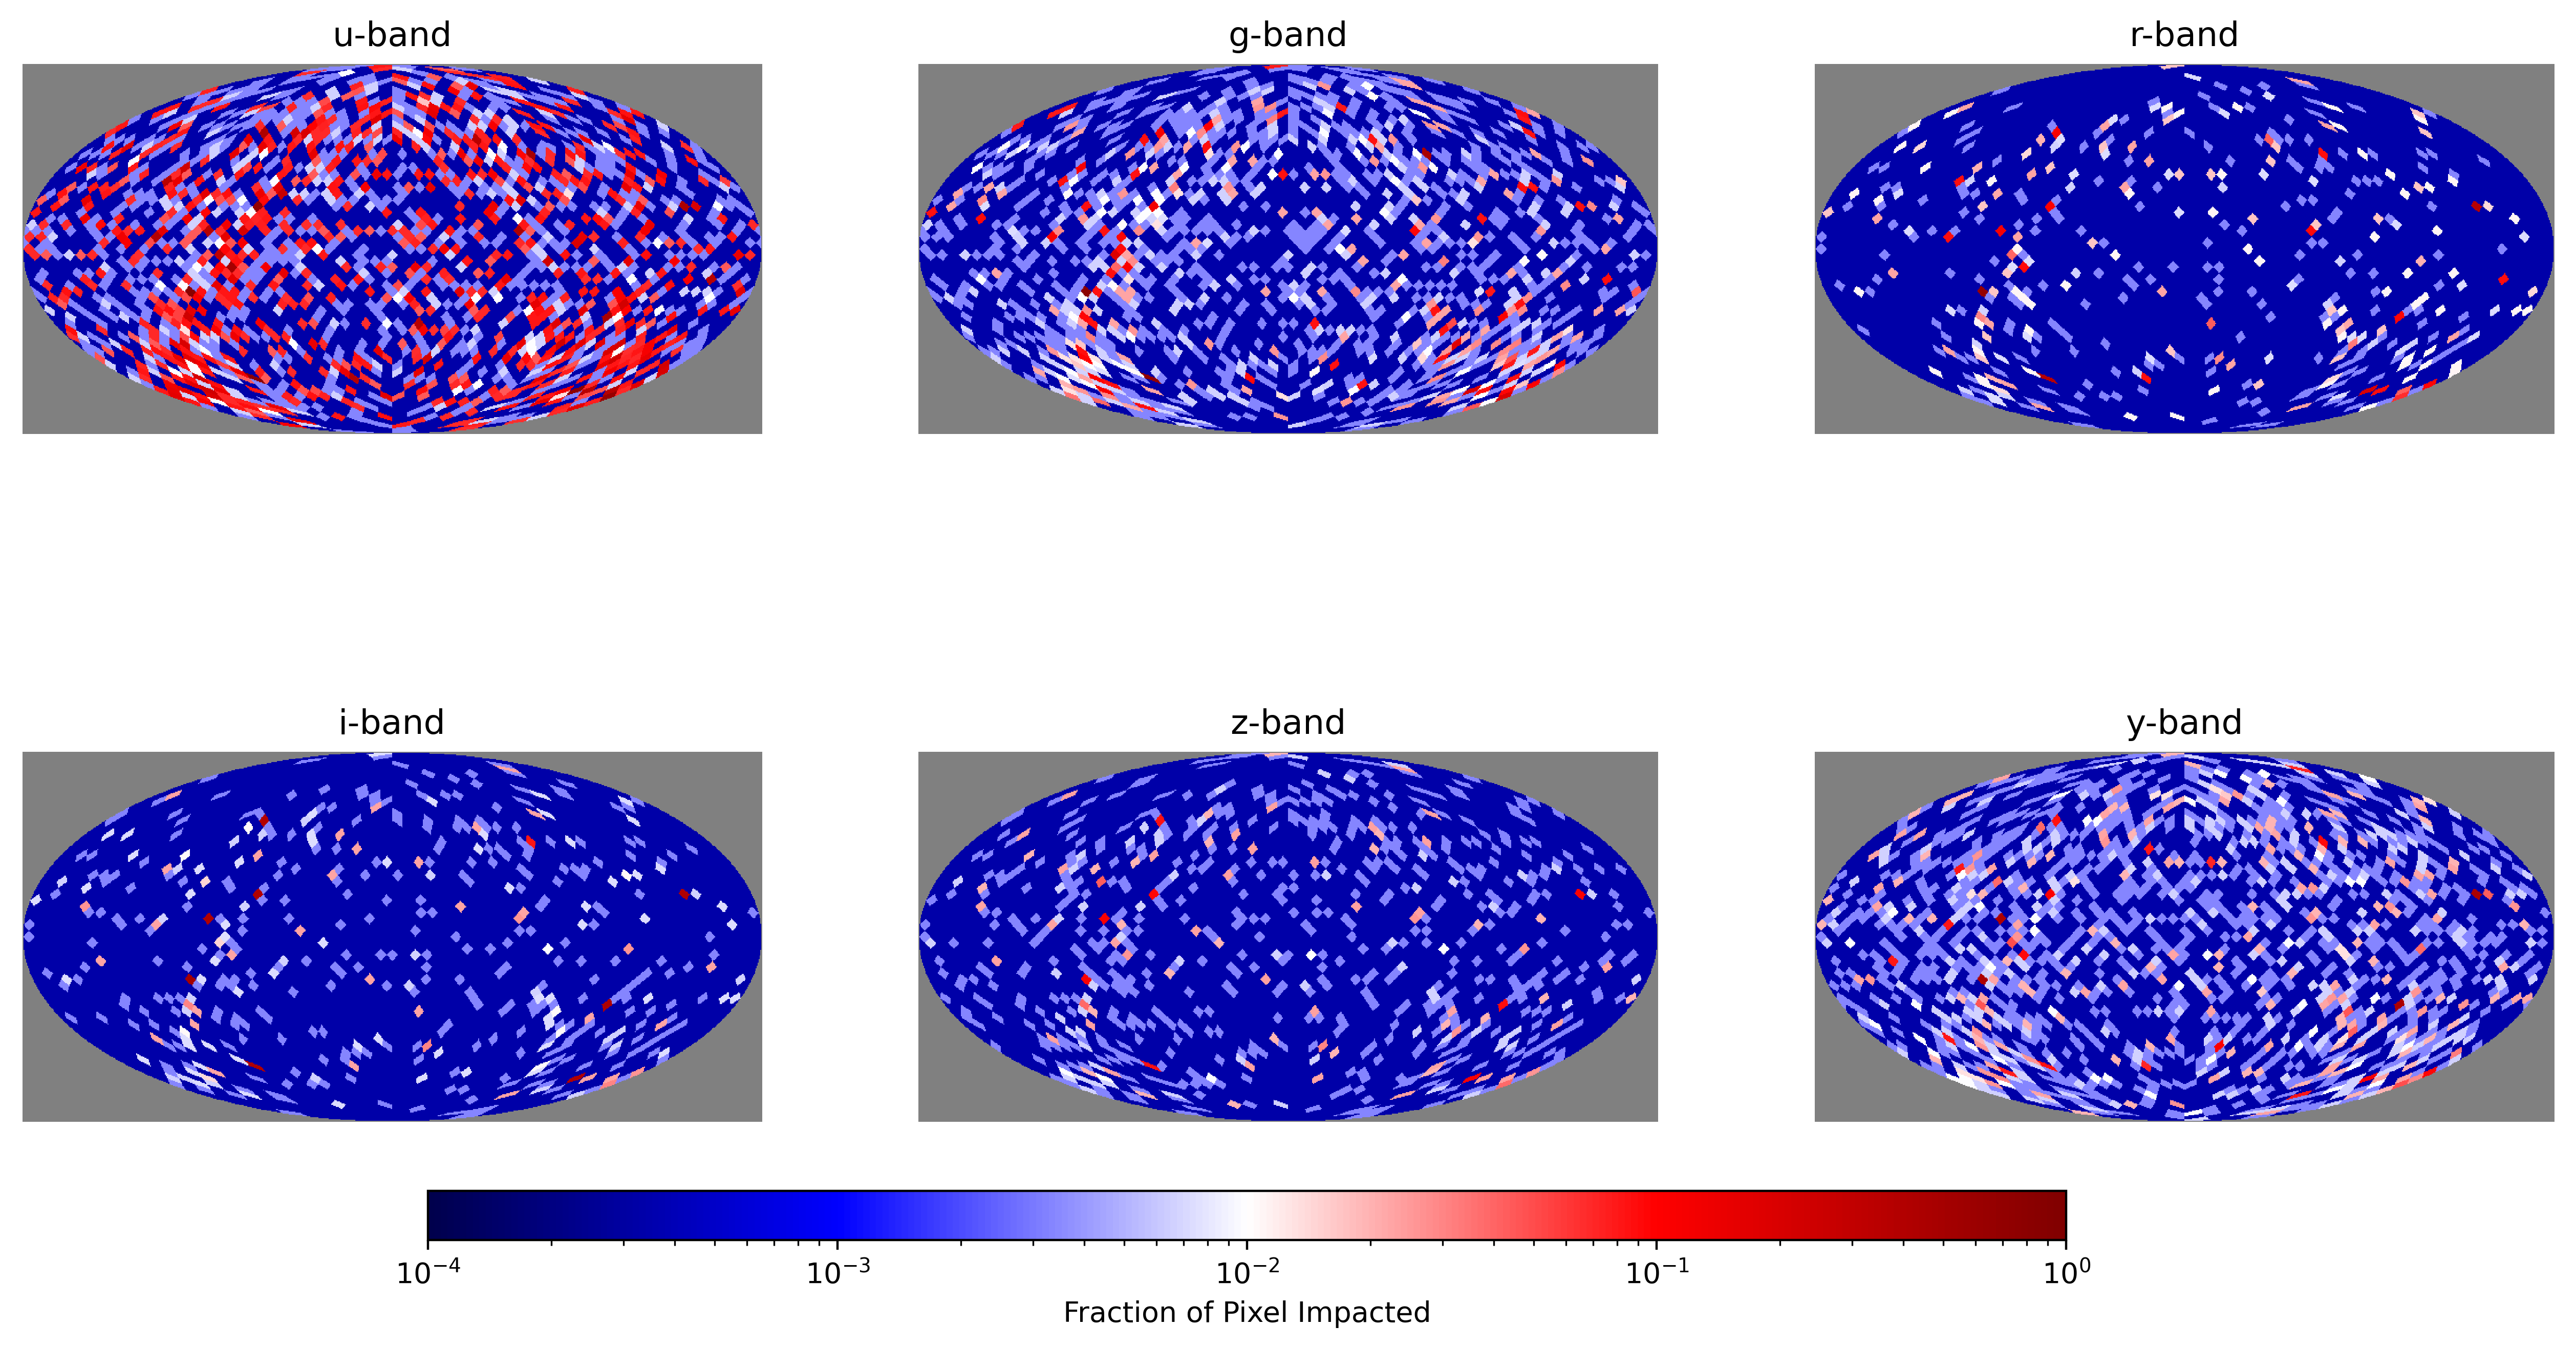

In [26]:
fig = plt.figure(figsize=(16, 8), dpi=400)

vmin, vmax = 1e-4, 1
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

for i, b in enumerate(bands, start=1):
    mask = (sim_table['band']==b) & (sim_table['fa_y']==0)
    area = (sim_table['impacted_area'][mask]*u.pixel**2 * rv.LSSTCamConstants.pixel_to_arcsec**2).to_value(u.deg**2)
    #(sim_table['impacted_area'][mask])/(sim_table['total_area'][mask])
    weights = []
    
    for mag in lsst_mags[b]:
        
        idx = np.argmin(np.abs(mag-star_mags))
        #print(b, mag, area[idx])
        weights.append(area[idx])
    
        
    nside = 16
    
    ra = ybsc['coord_ra']
    dec = ybsc['coord_dec']
    
    
    theta = np.radians(90.0 - dec)
    phi   = np.radians(ra)
    
    # compute pixel indices
    pix = hp.ang2pix(nside, theta, phi)
    
    # build a map by summing weights into each pixel
    npix = hp.nside2npix(nside)
    hp_map = np.bincount(pix, minlength=npix, weights=weights).astype(float)
    
    pix_area_sqdeg = hp.nside2pixarea(nside, degrees=True)
    hp_map_area = hp_map / pix_area_sqdeg
    hp_map_area[hp_map_area <= 0] = np.nanmin(hp_map_area[hp_map_area > 0]) / 10
    # Quick plot: Mollweide projection
    ax = plt.subplot(2, 3, i, projection="mollweide")
    hp.mollview(hp_map_area, title=f"{b}-band", min=vmin, max=vmax, norm=norm, cbar=False,
                unit="sq. deg.", cmap='seismic', bgcolor='white', hold=True)
    #hp.graticule()

cax = fig.add_axes([0.25, 0.1, 0.5, 0.03])  # [left, bottom, width, height]
#norm = plt.Normalize(vmin=vmin, vmax=vmax)
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap="seismic"),
    cax=cax,
    orientation="horizontal"
)
cb.set_label("Fraction of Pixel Impacted")
fig.patch.set_facecolor('white')
plt.show()

# Conclusion

As defined, the area of the focal plane impacted by ghosts in the DRP is calculated to be 0.57%, which is below the required value of 1%, **implying that the requirement is met.**

However, this number is highly dependent on the fields observed, as fields with a high number of bright stars can easily produce impacted areas of larger thatn 1%. From the plot that separates the impacted area in each band, the worst case in the u-band was as high as ~8%. Furthermore, it is not clear that the 1/3 sky noise threshold is sufficient to eliminate all impactful ghosts that is necessary to conduct low surface brightness science.